In [2]:
# Load packages
from costs_benefits_ssp.cb_calculate import CostBenefits
import pandas as pd
import os
import pathlib
import numpy as np

In [3]:
##---- Define Directories ----##
SCRIPT_DIR_PATH = os.getcwd()
PARENT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
OUTPUT_CB_PATH = os.path.join(SCRIPT_DIR_PATH, "out")
CONFIG_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "cb_config_files")
RUN_OUTPUT_DIR_PATH = os.path.join(PARENT_DIR_PATH, "ssp_run_output")
RUN_ID = "sisepuede_results_run_sisepuede_run_2026-03-13T07;36;11.592365"
RUN_DIR_PATH = os.path.join(RUN_OUTPUT_DIR_PATH, RUN_ID )   


In [4]:
RUN_DIR_PATH

'/Users/alexa/Projects/ssp_libya/ssp_modeling/ssp_run_output/sisepuede_results_run_sisepuede_run_2026-03-13T07;36;11.592365'

In [5]:
# Make sure output directory exists
os.makedirs(OUTPUT_CB_PATH, exist_ok=True)

In [6]:
## Load the data
ssp_data = pd.read_csv(os.path.join(RUN_DIR_PATH, "decomposed_ssp_output.csv"))
att_primary = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))
att_strategy = pd.read_csv(os.path.join(RUN_DIR_PATH, "ATTRIBUTE_STRATEGY.csv"))
print(f"Loaded ssp_data with {ssp_data.shape[0]} rows and {ssp_data.shape[1]} columns")
print(f"Loaded att_primary with {att_primary.shape[0]} rows and {att_primary.shape[1]} columns")
print(f"Loaded att_strategy with {att_strategy.shape[0]} rows and {att_strategy.shape[1]} columns")

Loaded ssp_data with 112 rows and 4054 columns
Loaded att_primary with 4 rows and 4 columns
Loaded att_strategy with 77 rows and 6 columns


In [7]:
att_strategy.head()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0


In [8]:
att_strategy.tail()

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
72,6001,PFLO:INC_IND_CCS,Singleton - Default Value - PFLO: Industrial c...,NaN,TX:PFLO:INC_IND_CCS,0
73,6002,PFLO:ALL,All Actions,All actions (unique by transformer),TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
74,6003,PFLO:NDC,NDC,NDC,TX:WALI:INC_TREATMENT_URBAN_STRATEGY_NDC|TX:WA...,0
75,6004,PFLO:LEP,LEP,LEP,TX:ENTC:TARGET_RENEWABLE_ELEC_STRATEGY_LEP|TX:...,0
76,6005,PFLO:CONDITIONAL,Conditional,Conditional,TX:INEN:INC_EFFICIENCY_PRODUCTION_STRATEGY_CON...,0


In [ ]:
## Define base strategy
strategy_code_base = "PFLO:NDC"

In [10]:
# Check if strategy_code_base exists in att_strategy
if strategy_code_base not in att_strategy['strategy_code'].values:
    raise ValueError(f"Base strategy code '{strategy_code_base}' not found in att_strategy.")

In [11]:
## Instantiate an object of the CostBenefits class
cb = CostBenefits(ssp_data, att_primary, att_strategy, strategy_code_base)

The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTransformationCode
The TX TX:ENFU:ADJ_EXPORTS is missing on AttTransformationCode
The TX TX:FRST:INCREASE_SEQUESTRATION is missing on AttTransformationCode
The TX TX:LNDU:BOUND_CLASSES is missing on AttTransformationCode
The TX TX:LNDU:DEC_CLASS_LOSS is missing on AttTransformationCode
The TX TX:SCOE:INC_EFFICIENCY_HEAT is missing on AttTr

In [12]:
# Once the excel file has been updated, we can reload it to update the cost factors database
cb.load_cb_parameters(os.path.join(CONFIG_DIR_PATH, "cb_config_params.xlsx"))

Cargamos configuración de archivo excel
Se actualizó la base de datos


In [13]:
# Compute System Costs
results_system = cb.compute_system_cost_for_all_strategies(verbose=False)


************************************
*Strategy : PFLO:NDC (0/3)
************************************


************************************
*Strategy : PFLO:LEP (1/3)
************************************


************************************
*Strategy : PFLO:CONDITIONAL (2/3)
************************************



In [14]:
# Compute Technical Costs
results_tx = cb.compute_technical_cost_for_all_strategies(verbose=False)


************************************
*Strategy : PFLO:NDC (0/3)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost

************************************
*Strategy : PFLO:LEP (1/3)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Tran

/opt/anaconda3/envs/ssp_libya_env_2/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1067: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output['variable_value_baseline'] = 0
/opt/anaconda3/envs/ssp_libya_env_2/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1070: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output['variable_value_pathway'] = data_merged["difference_value"]



************************************
*Strategy : PFLO:CONDITIONAL (2/3)
************************************

La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transform

/opt/anaconda3/envs/ssp_libya_env_2/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1067: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output['variable_value_baseline'] = 0
/opt/anaconda3/envs/ssp_libya_env_2/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:1070: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_output['variable_value_pathway'] = data_merged["difference_value"]


La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost
La variable se evalúa en Transformation Cost


In [15]:
# Combine results
results_all = pd.concat([results_system, results_tx], ignore_index = True)

In [16]:
#-------------POST PROCESS SIMULATION RESULTS---------------
# Post process interactions among strategies that affect the same variables
results_all_pp = cb.cb_process_interactions(results_all)

# SHIFT any stray costs incurred from 2015 to 2025 to 2025 and 2035
results_all_pp_shifted = cb.cb_shift_costs(results_all_pp)


Resolving Interactions in SCOE :  
No interactions, skipping... PFLO:NDC
Resolving Interactions in INEN :  
No interactions, skipping... PFLO:NDC
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:INC_EFFICIENCY_ENERGY 
Resolving Interactions in SCOE : TX:SCOE:INC_EFFICIENCY_APPLIANCE, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:SHIFT_FUEL_HEAT, TX:SCOE:DEC_DEMAND_HEAT 
Resolving Interactions in INEN : TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:SHIFT_FUEL_HEAT, TX:INEN:INC_EFFICIENCY_ENERGY 


/opt/anaconda3/envs/ssp_libya_env_2/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:660: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_pre2025["variable"] = res_pre2025["variable"] + "_shifted" + (res_pre2025["time_period"]+SSP_GLOBAL_TIME_PERIOD_0).astype(str)#create a new variable so they can be recognized as shifted costs
/opt/anaconda3/envs/ssp_libya_env_2/lib/python3.11/site-packages/costs_benefits_ssp/cb_calculate.py:661: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_pre2025["t

In [17]:
results_all_pp_shifted

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value
0,PFLO:NDC,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
1,PFLO:NDC,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
2,PFLO:NDC,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
3,PFLO:NDC,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
4,PFLO:NDC,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0
...,...,...,...,...,...,...,...,...,...,...
20035,PFLO:CONDITIONAL,0.0,libya,19.0,energy_consumption_inen_total,122.952305,122.952305,0.0,cb:inen:technical_cost:fuel_switch:all_shifted...,0.0
20036,PFLO:CONDITIONAL,0.0,libya,18.0,energy_consumption_inen_total,122.169331,122.169331,0.0,cb:inen:technical_savings:fuel_switch:all_shif...,-0.0
20037,PFLO:CONDITIONAL,0.0,libya,19.0,energy_consumption_inen_total,122.952305,122.952305,0.0,cb:inen:technical_savings:fuel_switch:all_shif...,-0.0
20038,PFLO:CONDITIONAL,0.0,libya,18.0,energy_consumption_inen_total,144.753543,144.753543,0.0,cb:inen:technical_cost:efficiency:X_shifted2023.0,0.0


In [18]:
results_all_pp_shifted.strategy_code.unique()

array(['PFLO:NDC', 'PFLO:LEP', 'PFLO:CONDITIONAL'], dtype=object)

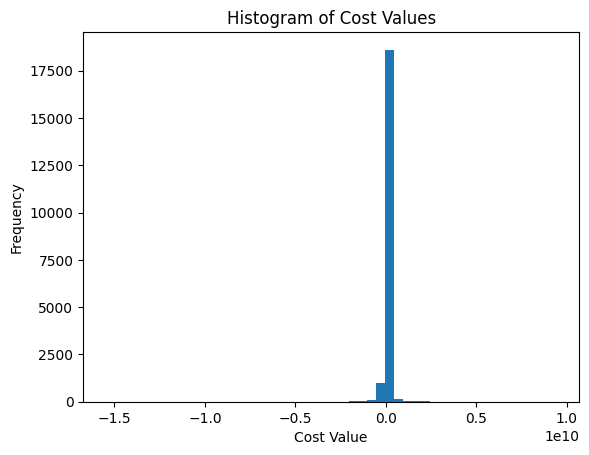

In [19]:
import matplotlib.pyplot as plt
plt.hist(results_all_pp_shifted.value, bins=50)
plt.title('Histogram of Cost Values')
plt.xlabel('Cost Value')
plt.ylabel('Frequency')
plt.show()

## Check for NaNs and Infs and DF Cleaning

In [20]:
# check nans
results_all_pp_shifted.value.isna().any()

np.False_

In [21]:
# check -inf or inf values
results_all_pp_shifted.value.isin([float('inf'), float('-inf')]).any()

np.False_

## Reshape to load into tableau

In [22]:
# --- Read cost-benefit data ---
cb_data = results_all_pp_shifted.copy()

# Split 'variable' into components: name, sector, cb_type, item_1, item_2
# (Assumes exactly 5 colon-separated parts; if there are more colons inside the last field,
# they will be kept in item_2 thanks to n=4)
cb_chars = cb_data["variable"].astype(str).str.split(":", n=4, expand=True)
cb_chars.columns = ["name", "sector", "cb_type", "item_1", "item_2"]
cb_data = pd.concat([cb_data, cb_chars], axis=1)

In [23]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2
0,PFLO:NDC,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
1,PFLO:NDC,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
2,PFLO:NDC,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
3,PFLO:NDC,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices
4,PFLO:NDC,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices


In [24]:
# Scale value from USD to billions (divide by 1e9)
if "value" in cb_data.columns:
    cb_data["value"] = cb_data["value"] / 1e9

# --- Remove "shifted" entries ---
# Remove rows where item_2 contains "shifted"
cb_data = cb_data[~cb_data["item_2"].astype(str).str.contains("shifted", na=False)]

# Remove any remaining rows where variable contains "shifted2"
cb_data = cb_data[~cb_data["variable"].astype(str).str.contains("shifted2", na=False)]

# --- Add Year column (Year = time_period + 2015) ---
cb_data["Year"] = cb_data["time_period"] + 2015

**This Section Needs Manual Tunnning**

In [25]:
cb_data.strategy_code.unique()

array(['PFLO:NDC', 'PFLO:LEP', 'PFLO:CONDITIONAL'], dtype=object)

In [26]:
# Harmonize strategy name changes with a single mapping (no duplicate replacements)
strategy_name_map = {
    "PFLO:NDC": "Business as Usual",
    "PFLO:LEP": "Unconditional",
    "PFLO:CONDITIONAL": "Conditional",
}

cb_data["strategy"] = (
    cb_data["strategy_code"].astype(str).map(strategy_name_map).fillna(cb_data["strategy_code"])
)
print(cb_data["strategy"].unique())


['Business as Usual' 'Unconditional' 'Conditional']


In [27]:
# --- Strategy ID mapping based on strategy_code ---
def map_strategy_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:NDC":
        return 6003
    if code == "PFLO:LEP":
        return 6004
    if code == "PFLO:CONDITIONAL":
        return 6005
    return code  # keep original if not matched

cb_data["strategy_id"] = cb_data["strategy_code"].astype(str).map(map_strategy_id)

In [28]:
ssp_data.primary_id.unique()

array([    0, 74074, 75075, 76076])

In [43]:
def map_primary_id(code: str):
    if code == "BASE":
        return 0
    if code == "PFLO:NDC":
        return 74074
    if code == "PFLO:LEP":
        return 75075
    if code == "PFLO:CONDITIONAL":
        return 76076
    return code  # keep original if not matched

cb_data["primary_id"] = cb_data["strategy_code"].astype(str).map(map_primary_id)


**Manual Tunning Ends Here**

In [44]:
# --- Create ids (variable:strategy_id) ---
cb_data["ids"] = cb_data["variable"].astype(str) + ":" + cb_data["strategy_id"].astype(str)

In [45]:
cb_data.head()

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,name,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids
0,PFLO:NDC,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2023.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...
1,PFLO:NDC,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2024.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...
2,PFLO:NDC,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2025.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...
3,PFLO:NDC,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2026.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...
4,PFLO:NDC,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.0,0.0,0.0,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.0,cb,agrc,crop_value,crops_produced,bevs_and_spices,2027.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...


In [46]:
cb_data.strategy.unique()

array(['Business as Usual', 'Unconditional', 'Conditional'], dtype=object)

In [47]:
cb_data.strategy_code.unique()

array(['PFLO:NDC', 'PFLO:LEP', 'PFLO:CONDITIONAL'], dtype=object)

In [48]:
# --- Read GDP and merge ---
# Keep only needed columns
gdp = ssp_data.loc[:, ["primary_id", "time_period", "gdp_mmm_usd"]]
gdp.head(100)

,primary_id,time_period,gdp_mmm_usd
0,0,8,101.162039
1,0,9,105.576742
2,0,10,107.688276
3,0,11,109.842042
4,0,12,112.038883
...,...,...,...
95,76076,19,128.697459
96,76076,20,131.271408
97,76076,21,133.896836
98,76076,22,136.574773


In [49]:
gdp[gdp['primary_id']== 75076]

,primary_id,time_period,gdp_mmm_usd


In [50]:
# Merge cb_data with gdp on primary_id and time_period
cb_data = cb_data.merge(gdp, on=["primary_id", "time_period"], how="left")
cb_data

,strategy_code,future_id,region,time_period,difference_variable,variable_value_baseline,variable_value_pathway,difference_value,variable,value,...,sector,cb_type,item_1,item_2,Year,strategy,strategy_id,primary_id,ids,gdp_mmm_usd
0,PFLO:NDC,0.0,libya,8.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2023.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,101.162039
1,PFLO:NDC,0.0,libya,9.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2024.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,105.576742
2,PFLO:NDC,0.0,libya,10.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2025.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,107.688276
3,PFLO:NDC,0.0,libya,11.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2026.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,109.842042
4,PFLO:NDC,0.0,libya,12.0,yield_agrc_bevs_and_spices_tonne,0.000000,0.000000,0.000000,cb:agrc:crop_value:crops_produced:bevs_and_spices,0.000000,...,agrc,crop_value,crops_produced,bevs_and_spices,2027.0,Business as Usual,6003,74074,cb:agrc:crop_value:crops_produced:bevs_and_spi...,112.038883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18699,PFLO:CONDITIONAL,0.0,libya,31.0,energy_consumption_inen_total,135.993790,50.589285,-85.404504,cb:inen:technical_cost:efficiency:X,-0.854045,...,inen,technical_cost,efficiency,X,2046.0,Conditional,6005,76076,cb:inen:technical_cost:efficiency:X:6005,163.219496
18700,PFLO:CONDITIONAL,0.0,libya,32.0,energy_consumption_inen_total,135.411255,47.963691,-87.447564,cb:inen:technical_cost:efficiency:X,-0.874476,...,inen,technical_cost,efficiency,X,2047.0,Conditional,6005,76076,cb:inen:technical_cost:efficiency:X:6005,166.483886
18701,PFLO:CONDITIONAL,0.0,libya,33.0,energy_consumption_inen_total,134.832761,45.476479,-89.356282,cb:inen:technical_cost:efficiency:X,-0.893563,...,inen,technical_cost,efficiency,X,2048.0,Conditional,6005,76076,cb:inen:technical_cost:efficiency:X:6005,169.813564
18702,PFLO:CONDITIONAL,0.0,libya,34.0,energy_consumption_inen_total,134.258682,43.119044,-91.139638,cb:inen:technical_cost:efficiency:X,-0.911396,...,inen,technical_cost,efficiency,X,2049.0,Conditional,6005,76076,cb:inen:technical_cost:efficiency:X:6005,173.209835


In [51]:
cb_data.isna().sum()

strategy_code                 0
future_id                     0
region                        0
time_period                   0
difference_variable           0
variable_value_baseline       0
variable_value_pathway       84
difference_value              0
variable                      0
value                         0
name                          0
sector                        0
cb_type                       0
item_1                        0
item_2                     1036
Year                          0
strategy                      0
strategy_id                   0
primary_id                    0
ids                           0
gdp_mmm_usd                   0
dtype: int64

## Save

In [52]:
cb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18704 entries, 0 to 18703
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   strategy_code            18704 non-null  object 
 1   future_id                18704 non-null  float64
 2   region                   18704 non-null  object 
 3   time_period              18704 non-null  float64
 4   difference_variable      18704 non-null  object 
 5   variable_value_baseline  18704 non-null  float64
 6   variable_value_pathway   18620 non-null  float64
 7   difference_value         18704 non-null  float64
 8   variable                 18704 non-null  object 
 9   value                    18704 non-null  float64
 10  name                     18704 non-null  object 
 11  sector                   18704 non-null  object 
 12  cb_type                  18704 non-null  object 
 13  item_1                   18704 non-null  object 
 14  item_2                

In [53]:
cb_data["Year"]

0        2023.0
1        2024.0
2        2025.0
3        2026.0
4        2027.0
          ...  
18699    2046.0
18700    2047.0
18701    2048.0
18702    2049.0
18703    2050.0
Name: Year, Length: 18704, dtype: float64

In [54]:
# Use .loc and avoid chained indexing; cast Year to int to be robust
selection = cb_data.loc[(cb_data["Year"] == 2027)]

In [55]:
cb_data.loc[
    (cb_data["variable"] == "cb:entc:technical_cost:electricity:capex") &
    (cb_data["value"] > 0),
    "value"
] = 0


In [56]:
# ensure no positive technical costs for electricity capex
mask = cb_data["variable"].astype(str).str.contains("cb:entc:technical_cost:electricity:capex", na=False)
cb_data.loc[mask, "value"] = -cb_data.loc[mask, "value"].abs()

# quick check
cb_data[mask]["value"].describe()

count    84.000000
mean     -0.543444
std       1.992256
min     -15.481288
25%      -0.367985
50%      -0.000117
75%       0.000000
max      -0.000000
Name: value, dtype: float64

In [57]:
cb_data[cb_data.variable == "cb:entc:technical_cost:electricity:capex"].describe()


,future_id,time_period,variable_value_baseline,variable_value_pathway,difference_value,value,Year,strategy_id,primary_id,gdp_mmm_usd
count,84.0,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,0.0,21.500000,542.694381,929.671565,386.977184,-0.543444,2036.500000,6004.000000,75075.000000,136.882164
std,0.0,8.126263,1262.077258,2697.382561,2117.890771,1.992256,8.126263,0.821401,822.221909,22.117109
min,0.0,8.000000,0.000000,0.000000,-4490.841666,-15.481288,2023.000000,6003.000000,74074.000000,101.162039
25%,0.0,14.750000,0.001960,24.159498,-35.573916,-0.367985,2029.750000,6003.000000,74074.000000,118.313732
50%,0.0,21.500000,297.938670,295.568023,0.122466,-0.000117,2036.500000,6004.000000,75075.000000,135.235805
75%,0.0,28.250000,465.600262,634.302663,367.984756,0.000000,2043.250000,6005.000000,76076.000000,154.574404
max,0.0,35.000000,6481.044315,21962.332764,15481.288449,-0.000000,2050.000000,6005.000000,76076.000000,176.674032


In [58]:
cb_data.to_csv(os.path.join(OUTPUT_CB_PATH, f"cb_{RUN_ID}.csv"), index = False)

In [59]:
os.path.join(OUTPUT_CB_PATH, f"cb_{RUN_ID}.csv")

'/Users/alexa/Projects/ssp_libya/ssp_modeling/cost-benefits/out/cb_sisepuede_results_run_sisepuede_run_2026-03-13T07;36;11.592365.csv'